In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from pat_data_processing.Utils import *

iat_df = pd.read_csv('data/processed_IAT_data_n80.csv')
pat_df = pd.read_csv('data/pat_diffes_with_accuracy_2024-09-23.csv')
non_diff_pat_df = pd.read_csv('data/pat_compiled_sheet_2024-09-23.csv')
iat_cols = iat_df.columns
pat_cols = pat_df.columns
print(iat_cols)

Index(['participant', 'gender', 'age', 'expName', 'date',
       'critical_blocks_percentage_accuracy', 'critical_blocks_mean_rt',
       'exclude_based_on_fast_trials', 'IAT_D1', 'IAT_D1a', 'IAT_D1b'],
      dtype='object')


In [2]:
def clean_iat_gender(iat_df):
    for i, row in enumerate(iat_df['gender']):
        print(row)
        if row.lower() in ['female', 'Female', 'F', 'f', 'woman']:
            iat_df['gender'].iloc[i] = "F"
        if row.lower() in ['male', 'Male', 'M', 'm']:
            iat_df['gender'].iloc[i] = "M"
        
clean_iat_gender(iat_df)

merged = iat_df.merge(pat_df, left_on='participant', right_on='pat_id')
merged_no_diff = iat_df.merge(non_diff_pat_df, left_on='participant', right_on='pat_id')

nonbinary
female
female
Male
Female
female
male
female
female
Female
Male
male
female
M
F
F
female
M
F
female
female
female
male
female
male
woman
female
female
male
female
female
female
nonbinary
female
female
male
female
female
female
male
male
transwoman
female
female
agender
female
male
Male
female
female
female
female
female
female
nonbinary
nonbinary
female
female
male
female
male
female
male
male
female
male
female
female
male
male
female
female
female
female
female
male


/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/201027634.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  iat_df['gender'].iloc[i] = "F"
/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/201027634.py:5: Se

In [3]:
print(iat_cols)
print(pat_cols)

Index(['participant', 'gender', 'age', 'expName', 'date',
       'critical_blocks_percentage_accuracy', 'critical_blocks_mean_rt',
       'exclude_based_on_fast_trials', 'IAT_D1', 'IAT_D1a', 'IAT_D1b'],
      dtype='object')
Index(['Q53', 'pat_id', 'coin positive player coins change',
       'coin positive e1 coins change', 'coin positive e2 coins change',
       'coin positive e3 coins change',
       'coin positive To what extent do you feel happy right now? change',
       'coin positive Confident? change', 'coin positive Stressed? change',
       'coin positive Excited? change',
       ...
       'speed diff How well are you playing this game right now? change',
       'speed ratio How well are you playing this game right now? change',
       'coin positive player most boolean',
       'coin negative player most boolean',
       'speed positive player most boolean',
       'speed negative player most boolean',
       'coin positive Which player do you think collected the most coins

In [4]:
# calculate accuracy
correct_cols = [col for col in merged.columns if 'correct' in col]
print(correct_cols)
merged['accuracy'] = merged[correct_cols].mean(axis=1)
merged['coin accuracy'] = merged[correct_cols[:2]].mean(axis=1)
merged['positive accuracy'] = merged[[correct_cols[0], correct_cols[2]]].mean(axis=1)
merged['negative accuracy'] = merged[[correct_cols[1], correct_cols[3]]].mean(axis=1)
merged['speed accuracy'] = merged[correct_cols[2:]].mean(axis=1)
# not availible for non_diff_pat_df

['coin positive Which player do you think collected the most coins? (select one) correct', 'coin negative Which player do you think collected the most coins? (select one) correct', 'speed positive Which player do you think collected the most coins? (select one) correct', 'speed negative Which player do you think collected the most coins? (select one) correct']


<Axes: xlabel='IAT_D1', ylabel='accuracy'>

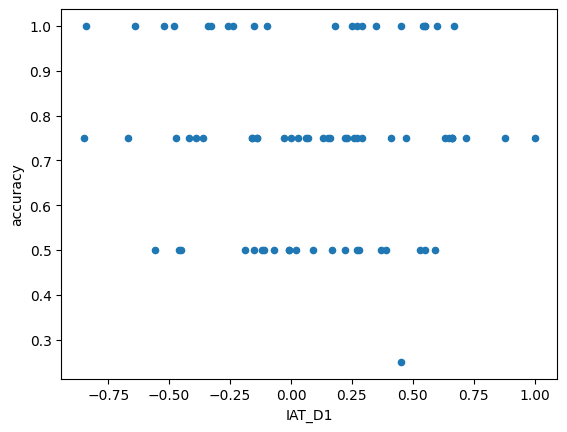

In [5]:
merged[['IAT_D1','accuracy']].corr()
merged[['IAT_D1','accuracy']].plot.scatter(x='IAT_D1', y='accuracy')

In [6]:
v0 = merged[merged["pat_id"] < 21]
print(v0["accuracy"].mean())
print(v0['coin accuracy'].mean())
print(v0['speed accuracy'].mean())
print(v0['positive accuracy'].mean())
print(v0['negative accuracy'].mean())
print(v0["IAT_D1"].mean())
print(v0["IAT_D1"].std())
print(v0["accuracy"].std())
print()
v1 = merged[(merged["pat_id"] < 66)]
print(v1["accuracy"].mean())
print(v1['coin accuracy'].mean())
print(v1['speed accuracy'].mean())
print(v1['positive accuracy'].mean())
print(v1['negative accuracy'].mean())
print(v1["IAT_D1"].mean())
print(v1["IAT_D1"].std())
print(v1["accuracy"].std())
print()
v2 = merged[merged["pat_id"] >= 66]
print(v2["accuracy"].mean())
print(v2['coin accuracy'].mean())
print(v2['speed accuracy'].mean())
print(v2['positive accuracy'].mean())
print(v2['negative accuracy'].mean())
print(v2["IAT_D1"].mean())
print(v2["IAT_D1"].std())
print(v2["accuracy"].std())

v0_no_diff = merged_no_diff[merged_no_diff["pat_id"] < 21]
v1_no_diff = merged_no_diff[(merged_no_diff["pat_id"] < 66)]
v2_no_diff = merged_no_diff[merged_no_diff["pat_id"] >= 66]

0.7375
0.625
0.85
0.725
0.75
-0.05450000000000001
0.40061104643571155
0.15120132970732486

0.7622950819672131
0.6557377049180327
0.8688524590163934
0.7459016393442623
0.7786885245901639
0.05606557377049181
0.43604769879958694
0.1959285026280671

0.6666666666666666
0.6666666666666666
0.6666666666666666
0.6666666666666666
0.6666666666666666
0.26666666666666666
0.2978414407189231
0.1809367161139365


In [25]:
# V1 V2 T TEST
print(scipy.stats.ttest_ind(v1["IAT_D1"], v2["IAT_D1"]))

TtestResult(statistic=np.float64(-1.767387272017927), pvalue=np.float64(0.0812860790530426), df=np.float64(74.0))


PearsonRResult(statistic=np.float64(0.01862073388499573), pvalue=np.float64(0.8867354748728329))
PearsonRResult(statistic=np.float64(0.0008722123916142209), pvalue=np.float64(0.994677140066116))
PearsonRResult(statistic=np.float64(0.029249840772106864), pvalue=np.float64(0.8229360486804146))
PearsonRResult(statistic=np.float64(0.0692689972629624), pvalue=np.float64(0.5957973799415427))
PearsonRResult(statistic=np.float64(-0.05695165790124997), pvalue=np.float64(0.6628666784621119))


<Axes: xlabel='IAT_D1', ylabel='accuracy'>

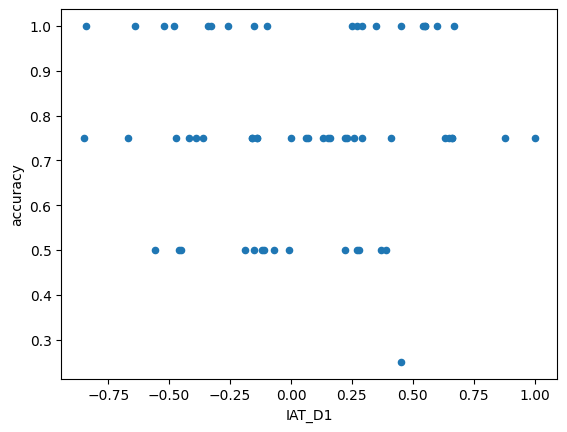

In [7]:
print(scipy.stats.pearsonr(v1['IAT_D1'], v1['accuracy']))
print(scipy.stats.pearsonr(v1['IAT_D1'], v1['coin accuracy']))
print(scipy.stats.pearsonr(v1['IAT_D1'], v1['speed accuracy']))
print(scipy.stats.pearsonr(v1['IAT_D1'], v1['positive accuracy']))
print(scipy.stats.pearsonr(v1['IAT_D1'], v1['negative accuracy']))
v1[['IAT_D1','accuracy']].plot.scatter(x='IAT_D1', y='accuracy')

PearsonRResult(statistic=np.float64(-0.22090669900455082), pvalue=np.float64(0.42883145295293157))
PearsonRResult(statistic=np.float64(-0.3309341612432629), pvalue=np.float64(0.2282695983659399))
PearsonRResult(statistic=np.float64(0.00259036065615377), pvalue=np.float64(0.9926899054814468))
PearsonRResult(statistic=np.float64(0.034267250510745084), pvalue=np.float64(0.9035032038917974))
PearsonRResult(statistic=np.float64(-0.30436737709807027), pvalue=np.float64(0.2700379446790011))


<Axes: xlabel='IAT_D1', ylabel='accuracy'>

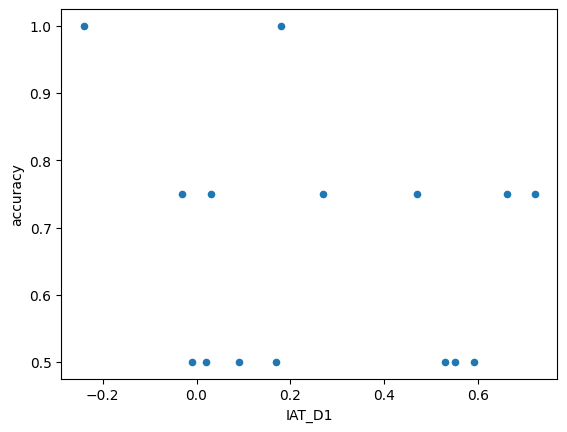

In [8]:
print(scipy.stats.pearsonr(v2['IAT_D1'], v2['accuracy']))
print(scipy.stats.pearsonr(v2['IAT_D1'], v2['coin accuracy']))
print(scipy.stats.pearsonr(v2['IAT_D1'], v2['speed accuracy']))
print(scipy.stats.pearsonr(v2['IAT_D1'], v2['positive accuracy']))
print(scipy.stats.pearsonr(v2['IAT_D1'], v2['negative accuracy']))
v2[['IAT_D1','accuracy']].plot.scatter(x='IAT_D1', y='accuracy')



PearsonRResult(statistic=np.float64(-0.07483368010965953), pvalue=np.float64(0.7538572915252248))


<Axes: xlabel='IAT_D1', ylabel='accuracy'>

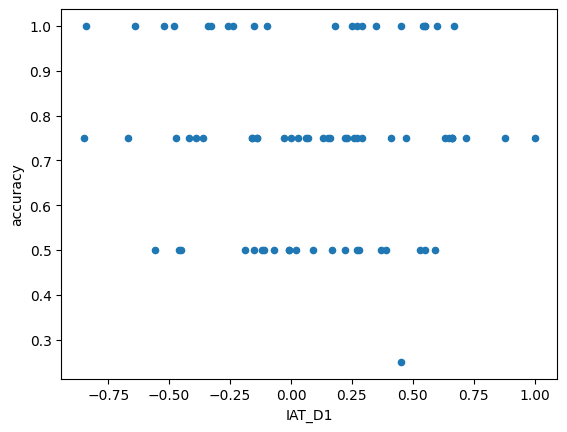

In [9]:
print(scipy.stats.pearsonr(v0['IAT_D1'], v0['accuracy']))
merged[['IAT_D1','accuracy']].plot.scatter(x='IAT_D1', y='accuracy')

In [10]:
d_dict = {}
p_dict = {}
for col in pat_cols:
    if v1[col].dtype == 'object':
        continue
    if v1[col].dtype == 'bool':
        continue
    v1_mean = v1[col].mean()
    v2_mean = v2[col].mean()
    v1_std = v1[col].std()
    v2_std = v2[col].std()
    test = scipy.stats.ttest_ind(v1[col], v2[col])
    pval = test.pvalue
    cohens_d = (v1_mean - v2_mean) / np.sqrt((v1_std**2 + v2_std**2) / 2)
    print(f"v1 vs v2 d: {cohens_d} for {col}")
    print(f"v1 vs v2 p: {pval} for {col}")
    p_dict[col] = pval
    d_dict[col] = cohens_d
    
d_df = pd.DataFrame.from_dict(d_dict, orient='index', columns=['d'])
p_df = pd.DataFrame.from_dict(p_dict, orient='index', columns=['p'])
d_df.to_csv('data/v1_v2_d.csv')
p_df.to_csv('data/v1_v2_p_diffs.csv')

v1 vs v2 d: -2.8489824298876676 for pat_id
v1 vs v2 p: 1.8546255864096882e-11 for pat_id
v1 vs v2 d: -0.41536633605941514 for coin positive player coins change
v1 vs v2 p: 0.21033027976008054 for coin positive player coins change
v1 vs v2 d: -0.3137971720361877 for coin positive e1 coins change
v1 vs v2 p: 0.3116308778193434 for coin positive e1 coins change
v1 vs v2 d: -0.15740417118621164 for coin positive e2 coins change
v1 vs v2 p: 0.6154574822315231 for coin positive e2 coins change
v1 vs v2 d: 0.7929363453914587 for coin positive e3 coins change
v1 vs v2 p: 0.007326716597452264 for coin positive e3 coins change
v1 vs v2 d: 0.1369029301011412 for coin positive To what extent do you feel happy right now? change
v1 vs v2 p: 0.6749271982919103 for coin positive To what extent do you feel happy right now? change
v1 vs v2 d: 0.04142968927673437 for coin positive Confident? change
v1 vs v2 p: 0.9040568580266002 for coin positive Confident? change
v1 vs v2 d: 0.359019803223389 for coin p

/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/3811375234.py:14: RuntimeWarning: invalid value encountered in scalar divide
  cohens_d = (v1_mean - v2_mean) / np.sqrt((v1_std**2 + v2_std**2) / 2)
/Users/lwang/pat-data-processing/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/lwang/pat-data-processing/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/lwang/pat-data-processing/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6527: RuntimeWarning: invalid value encountered in scalar subtract
  d = mean1 - mean2
/Users/lwang/pat-data-processing/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py

In [11]:
moodcols = [" ".join((block, col, "change")) for block in SHORT_BLOCKTYPES for col in QUESTIONTYPES[10:12]]
v1[moodcols]

,coin positive How much would you like to keep playing this game? change,coin positive How well are you playing this game right now? change,coin negative How much would you like to keep playing this game? change,coin negative How well are you playing this game right now? change,speed positive How much would you like to keep playing this game? change,speed positive How well are you playing this game right now? change,speed negative How much would you like to keep playing this game? change,speed negative How well are you playing this game right now? change
0,8.0,7.0,7.0,5.0,6.0,6.0,5.0,4.0
1,5.0,3.0,5.0,2.0,3.0,2.0,3.0,3.0
2,3.0,4.0,3.0,3.0,3.0,5.0,2.0,2.0
3,9.0,8.0,9.0,8.0,10.0,9.0,10.0,1.0
4,9.0,4.0,9.0,5.0,7.0,5.0,7.0,4.0
...,...,...,...,...,...,...,...,...
71,6.0,5.0,7.0,5.0,6.0,5.0,6.0,5.0
72,3.0,7.0,3.0,3.0,4.0,7.0,1.0,2.0
73,10.0,9.0,10.0,8.0,10.0,8.0,10.0,6.0
74,6.0,6.0,6.0,3.0,6.0,7.0,4.0,2.0


In [12]:
gmm_cols = [col for col in v1.columns if 'gmm' in col]
print(gmm_cols)

['coin positive gmm average change', 'coin positive gmm first third average change', 'coin positive gmm second third average change', 'coin positive gmm third third average change', 'coin positive gmm std change', 'coin positive gmm first third std change', 'coin positive gmm second third std change', 'coin positive gmm third third std change', 'coin positive gmm area under the curve change', 'coin: neutral -> positive (post-manipulation) gmm average', 'coin: neutral -> positive (post-manipulation) gmm first third average', 'coin: neutral -> positive (post-manipulation) gmm second third average', 'coin: neutral -> positive (post-manipulation) gmm third third average', 'coin: neutral -> positive (post-manipulation) gmm std', 'coin: neutral -> positive (post-manipulation) gmm first third std', 'coin: neutral -> positive (post-manipulation) gmm second third std', 'coin: neutral -> positive (post-manipulation) gmm third third std', 'coin: neutral -> positive (post-manipulation) gmm area un

In [13]:
num_questions = [
    "player coins",
    "To what extent do you feel happy right now?",
    "Confident?",
    "Stressed?",
    "Excited?",
    "Frustrated?",
    "How much would you like to keep playing this game?",
    "How well are you playing this game right now?",
    "gmm average",
    "gmm first third average",
    "gmm second third average",
    "gmm third third average",
    "gmm std",
    "gmm first third std",
    "gmm second third std",
    "gmm third third std",
    
]

for col in num_questions:
    print(col)
    v0_vals = []
    v1_vals = []
    v2_vals = []
    merged_vals = []
    for block in SHORT_BLOCKTYPES:
        block_col = " ".join((block, col, "change"))
        v0_vals.append(v0[block_col].values)
        v1_vals.append(v1[block_col].values)
        v2_vals.append(v2[block_col].values)
        merged_vals.append(merged[block_col].values)
    score_col_name = " ".join((col, "combined score"))
    v0[score_col_name] = ((v0_vals[0] - v0_vals[1]) + (v0_vals[2] - v0_vals[3])) / 2
    v1[score_col_name] = ((v1_vals[0] - v1_vals[1]) + (v1_vals[2] - v1_vals[3])) / 2
    v2[score_col_name] = ((v2_vals[0] - v2_vals[1]) + (v2_vals[2] - v2_vals[3])) / 2
    merged[score_col_name] = ((merged_vals[0] - merged_vals[1]) + (merged_vals[2] - merged_vals[3])) / 2

player coins
To what extent do you feel happy right now?
Confident?
Stressed?
Excited?
Frustrated?
How much would you like to keep playing this game?
How well are you playing this game right now?
gmm average
gmm first third average
gmm second third average
gmm third third average
gmm std
gmm first third std
gmm second third std
gmm third third std


/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/1983391373.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v0[score_col_name] = ((v0_vals[0] - v0_vals[1]) + (v0_vals[2] - v0_vals[3])) / 2
/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/1983391373.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v1[score_col_name] = ((v1_vals[0] - v1_vals[1]) + (v1_vals[2] - v1_vals[3])) / 2
/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/1983391373.py:36: SettingWi

In [14]:
combined_scores = [col for col in v0.columns if "combined score" in col]
for col in combined_scores:
    print(col)
    v0_vals = v0[col].values
    v1_vals = v1[col].values
    v2_vals = v2[col].values
    test = scipy.stats.ttest_ind(v1_vals, v2_vals)
    pval = test.pvalue
    cohens_d = (v1_vals.mean() - v2_vals.mean()) / np.sqrt((v1_vals.std()**2 + v2_vals.std()**2) / 2)
    print(f"v1 vs v2 d: {cohens_d} for {col}")
    print(f"v1 vs v2 p: {pval} for {col}")
    v0_iat_corr = scipy.stats.pearsonr(v0['IAT_D1'], v0[col])
    v1_iat_corr = scipy.stats.pearsonr(v1['IAT_D1'], v1[col])
    v2_iat_corr = scipy.stats.pearsonr(v2['IAT_D1'], v2[col])
    print(f"v0 IAT corr: {v0_iat_corr} for {col}")
    print(f"v1 IAT corr: {v1_iat_corr} for {col}")
    print(f"v2 IAT corr: {v2_iat_corr} for {col}")
    
    p_dict[col] = pval
    d_dict[col] = cohens_d

player coins combined score
v1 vs v2 d: -1.167866121922059 for player coins combined score
v1 vs v2 p: 0.001062624047345868 for player coins combined score
v0 IAT corr: PearsonRResult(statistic=np.float64(-0.24908319001194465), pvalue=np.float64(0.28959304478491)) for player coins combined score
v1 IAT corr: PearsonRResult(statistic=np.float64(-0.16104059979878485), pvalue=np.float64(0.21502789743452183)) for player coins combined score
v2 IAT corr: PearsonRResult(statistic=np.float64(0.16050360794765323), pvalue=np.float64(0.5677116523405832)) for player coins combined score
To what extent do you feel happy right now? combined score
v1 vs v2 d: -0.6042265568671027 for To what extent do you feel happy right now? combined score
v1 vs v2 p: 0.0676655153190222 for To what extent do you feel happy right now? combined score
v0 IAT corr: PearsonRResult(statistic=np.float64(0.0846840560869039), pvalue=np.float64(0.7226107488361933)) for To what extent do you feel happy right now? combined sco

In [15]:
cols = [col for col in v1_no_diff.columns if 'How much' in col]
print(cols)


['coin: neutral -> positive (post-block) How much would you like to keep playing this game?', 'coin: neutral -> negative (post-block) How much would you like to keep playing this game?', 'speed: neutral -> negative (post-block) How much would you like to keep playing this game?', 'speed: neutral -> positive (post-block) How much would you like to keep playing this game?', 'End of game questions How much did you enjoy playing this game?']


In [16]:
blocks = ["coin: neutral -> positive", "coin: neutral -> negative", "speed: neutral -> positive", "speed: neutral -> negative"]
num_questions = [
    "player coins",
    "To what extent do you feel happy right now?",
    "Confident?",
    "Stressed?",
    "Excited?",
    "Frustrated?",
    "gmm average",
    "gmm first third average",
    "gmm second third average",
    "gmm third third average",
    "gmm std",
    "gmm first third std",
    "gmm second third std",
    "gmm third third std",
]

num_questions_post_block = ["How much would you like to keep playing this game?",
    "How well are you playing this game right now?",]

for col in num_questions:
    print(col)
    v0_vals = []
    v1_vals = []
    v2_vals = []
    merged_vals = []
    for block in blocks:
        block_col = " ".join((block, "(post-manipulation)", col))
        v0_vals.append(v0_no_diff[block_col].values)
        v1_vals.append(v1_no_diff[block_col].values)
        v2_vals.append(v2_no_diff[block_col].values)
        merged_vals.append(merged_no_diff[block_col].values)
    score_col_name = " ".join((col, "combined score"))
    v0_no_diff[score_col_name] = ((v0_vals[0] - v0_vals[1]) + (v0_vals[2] - v0_vals[3])) / 2
    v1_no_diff[score_col_name] = ((v1_vals[0] - v1_vals[1]) + (v1_vals[2] - v1_vals[3])) / 2
    v2_no_diff[score_col_name] = ((v2_vals[0] - v2_vals[1]) + (v2_vals[2] - v2_vals[3])) / 2
    merged_no_diff[score_col_name] = ((merged_vals[0] - merged_vals[1]) + (merged_vals[2] - merged_vals[3])) / 2
    
for col in num_questions_post_block:
    print(col)
    v0_vals = []
    v1_vals = []
    v2_vals = []
    merged_vals = []
    for block in blocks:
        block_col = " ".join((block, "(post-block)", col))
        v0_vals.append(v0_no_diff[block_col].values)
        v1_vals.append(v1_no_diff[block_col].values)
        v2_vals.append(v2_no_diff[block_col].values)
        merged_vals.append(merged_no_diff[block_col].values)
    score_col_name = " ".join((col, "combined score"))
    v0_no_diff[score_col_name] = ((v0_vals[0] - v0_vals[1]) + (v0_vals[2] - v0_vals[3])) / 2
    v1_no_diff[score_col_name] = ((v1_vals[0] - v1_vals[1]) + (v1_vals[2] - v1_vals[3])) / 2
    v2_no_diff[score_col_name] = ((v2_vals[0] - v2_vals[1]) + (v2_vals[2] - v2_vals[3])) / 2
    merged_no_diff[score_col_name] = ((merged_vals[0] - merged_vals[1]) + (merged_vals[2] - merged_vals[3])) / 2    

player coins
To what extent do you feel happy right now?
Confident?
Stressed?
Excited?
Frustrated?
gmm average
gmm first third average
gmm second third average
gmm third third average
gmm std
gmm first third std
gmm second third std
gmm third third std
How much would you like to keep playing this game?
How well are you playing this game right now?


/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/3069965585.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v0_no_diff[score_col_name] = ((v0_vals[0] - v0_vals[1]) + (v0_vals[2] - v0_vals[3])) / 2
/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/3069965585.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v1_no_diff[score_col_name] = ((v1_vals[0] - v1_vals[1]) + (v1_vals[2] - v1_vals[3])) / 2
/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/3069965585.

In [17]:
combined_scores = [col for col in v0_no_diff.columns if "combined score" in col]
for col in combined_scores:
    print(col)
    v0_vals = v0_no_diff[col].values
    v1_vals = v1_no_diff[col].values
    v2_vals = v2_no_diff[col].values
    test = scipy.stats.ttest_ind(v1_vals, v2_vals)
    pval = test.pvalue
    cohens_d = (v1_vals.mean() - v2_vals.mean()) / np.sqrt((v1_vals.std()**2 + v2_vals.std()**2) / 2)
    print(f"v1 vs v2 d: {cohens_d} for {col}")
    print(f"v1 vs v2 p: {pval} for {col}")
    v0_iat_corr = scipy.stats.pearsonr(v0['IAT_D1'], v0[col])
    v1_iat_corr = scipy.stats.pearsonr(v1['IAT_D1'], v1[col])
    v2_iat_corr = scipy.stats.pearsonr(v2['IAT_D1'], v2[col])
    print(f"v0 IAT corr: {v0_iat_corr} for {col}")
    print(f"v1 IAT corr: {v1_iat_corr} for {col}")
    print(f"v2 IAT corr: {v2_iat_corr} for {col}")
    
    p_dict[col] = pval
    d_dict[col] = cohens_d

player coins combined score
v1 vs v2 d: 1.2540655579516318 for player coins combined score
v1 vs v2 p: 0.000868993410171542 for player coins combined score
v0 IAT corr: PearsonRResult(statistic=np.float64(-0.24908319001194465), pvalue=np.float64(0.28959304478491)) for player coins combined score
v1 IAT corr: PearsonRResult(statistic=np.float64(-0.16104059979878485), pvalue=np.float64(0.21502789743452183)) for player coins combined score
v2 IAT corr: PearsonRResult(statistic=np.float64(0.16050360794765323), pvalue=np.float64(0.5677116523405832)) for player coins combined score
To what extent do you feel happy right now? combined score
v1 vs v2 d: 0.5265936888769075 for To what extent do you feel happy right now? combined score
v1 vs v2 p: 0.12795609480289108 for To what extent do you feel happy right now? combined score
v0 IAT corr: PearsonRResult(statistic=np.float64(0.0846840560869039), pvalue=np.float64(0.7226107488361933)) for To what extent do you feel happy right now? combined sco

In [18]:
blocks = ["coin: neutral -> positive", "coin: neutral -> negative", "speed: neutral -> positive", "speed: neutral -> negative"]
num_questions = [
    "player coins",
    "To what extent do you feel happy right now?",
    "Confident?",
    "Stressed?",
    "Excited?",
    "Frustrated?",
    "gmm average",
    "gmm first third average",
    "gmm second third average",
    "gmm third third average",
    "gmm std",
    "gmm first third std",
    "gmm second third std",
    "gmm third third std",
]

num_questions_post_block = ["How much would you like to keep playing this game?",
    "How well are you playing this game right now?",]

for col in num_questions:
    for block in blocks:
        print(block)
        block_col = " ".join((block, "(post-manipulation)", col))
        v0_vals = v0_no_diff[block_col].values
        v1_vals = v1_no_diff[block_col].values
        v2_vals = v2_no_diff[block_col].values
        test = scipy.stats.ttest_ind(v1_vals, v2_vals)
        pval = test.pvalue
        cohens_d = (v1_vals.mean() - v2_vals.mean()) / np.sqrt((v1_vals.std()**2 + v2_vals.std()**2) / 2)
        print(f"v1 vs v2 d: {cohens_d} for {block_col}")
        print(f"v1 vs v2 p: {pval} for {block_col}")
        v0_iat_corr = scipy.stats.pearsonr(v0['IAT_D1'], v0[block_col])
        v1_iat_corr = scipy.stats.pearsonr(v1['IAT_D1'], v1[block_col])
        v2_iat_corr = scipy.stats.pearsonr(v2['IAT_D1'], v2[block_col])
        print(f"v0 IAT corr: {v0_iat_corr} for {block_col}")
        print(f"v1 IAT corr: {v1_iat_corr} for {block_col}")
        print(f"v2 IAT corr: {v2_iat_corr} for {block_col}")

        p_dict[block_col] = pval
        d_dict[block_col] = cohens_d

coin: neutral -> positive
v1 vs v2 d: 0.3076697072338979 for coin: neutral -> positive (post-manipulation) player coins
v1 vs v2 p: 0.3680806002435951 for coin: neutral -> positive (post-manipulation) player coins
v0 IAT corr: PearsonRResult(statistic=np.float64(0.1091767242194031), pvalue=np.float64(0.6468168983706308)) for coin: neutral -> positive (post-manipulation) player coins
v1 IAT corr: PearsonRResult(statistic=np.float64(0.12699920289951108), pvalue=np.float64(0.329395663723847)) for coin: neutral -> positive (post-manipulation) player coins
v2 IAT corr: PearsonRResult(statistic=np.float64(0.22025415979896532), pvalue=np.float64(0.4302311435950838)) for coin: neutral -> positive (post-manipulation) player coins
coin: neutral -> negative
v1 vs v2 d: -0.32065848667069496 for coin: neutral -> negative (post-manipulation) player coins
v1 vs v2 p: 0.33201196035090397 for coin: neutral -> negative (post-manipulation) player coins
v0 IAT corr: PearsonRResult(statistic=np.float64(0.1

/Users/lwang/pat-data-processing/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/var/folders/15/_7jw71x17_nd9f6wldr33w8r0000gn/T/ipykernel_49922/1080374175.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  v2_iat_corr = scipy.stats.pearsonr(v2['IAT_D1'], v2[block_col])


In [19]:
end_qs = [col for col in pat_cols if "End of game questions" in col]
end_qs

['End of game questions Please rank the players from who got the MOST coins to who got the LEAST (You, P2, P3, P4)',
 'End of game questions Overall, how fair was this game?',
 'End of game questions How much did you enjoy playing this game?',
 'End of game questions How likely are you to recommend this game to a friend?']

In [20]:
QUESTIONTYPES

['player coins',
 'e1 coins',
 'e2 coins',
 'e3 coins',
 'To what extent do you feel happy right now?',
 'Confident?',
 'Stressed?',
 'Excited?',
 'Frustrated?',
 'Proud?',
 'How much would you like to keep playing this game?',
 'How well are you playing this game right now?',
 'Which player do you think collected the most coins? (select one)',
 'Please rank the players from who got the MOST coins to who got the LEAST (You, P2, P3, P4)',
 'Overall, how fair was this game?',
 'How much did you enjoy playing this game?',
 'How likely are you to recommend this game to a friend?']

In [21]:
for col in end_qs[1:]:
    print(scipy.stats.pearsonr(v1['IAT_D1'], v1[col]))

PearsonRResult(statistic=np.float64(-0.11669789646271936), pvalue=np.float64(0.37044000996304494))
PearsonRResult(statistic=np.float64(-0.033633433183452986), pvalue=np.float64(0.7969287479789762))
PearsonRResult(statistic=np.float64(-0.02187715514271029), pvalue=np.float64(0.8670937422816895))


In [22]:
for col in end_qs[1:]:
    print(v1[['IAT_D1',col]].corr())

                                                      IAT_D1  \
IAT_D1                                              1.000000   
End of game questions Overall, how fair was thi... -0.116698   

                                                    End of game questions Overall, how fair was this game?  
IAT_D1                                                                                      -0.116698       
End of game questions Overall, how fair was thi...                                           1.000000       
                                                      IAT_D1  \
IAT_D1                                              1.000000   
End of game questions How much did you enjoy pl... -0.033633   

                                                    End of game questions How much did you enjoy playing this game?  
IAT_D1                                                                                      -0.033633                
End of game questions How much did you enjoy pl... 

In [23]:
merged.to_csv('data/merged_iat_pat_9_9.csv')